In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Define the corrected file path for Togo
file_path = 'C:/Users/Home-User/solar-challenge-week0/data/togo-dapaong_qc.csv'

# 1. Load the data, parsing 'Timestamp'
df = pd.read_csv(file_path, parse_dates=['Timestamp'])

# --- Debugging Check for Indexing ---
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")

# 2. Set Timestamp as the index
df = df.set_index('Timestamp')
print(f"Initial Dataset Shape: {df.shape}")
print(f"Initial Columns: {df.columns.tolist()}")

# Check for duplicate timestamps
if df.index.duplicated().any():
    print("\n⚠️ WARNING: Duplicate timestamps found. Aggregating means.")
    df = df.groupby(df.index).mean()
    print(f"Shape after resolving duplicates: {df.shape}")
# -----------------------------------

# 3. Summary Statistics
print("\n--- Summary Statistics (df.describe()) ---")
print(df.describe().T)

# 4. Missing Value Report
null_report = df.isna().sum().sort_values(ascending=False)
print("\n--- Missing Value Report (df.isna().sum()) ---")
print(null_report[null_report > 0]) 

# 5. Columns with >5% nulls
threshold = len(df) * 0.05
major_null_cols = null_report[null_report > threshold].index.tolist()
print("\n--- Columns with >5% Nulls ---")
if major_null_cols:
    print(major_null_cols)
else:
    print("No columns exceed the 5% null threshold.")

Initial Dataset Shape: (525600, 18)
Initial Columns: ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB', 'Comments']

--- Summary Statistics (df.describe()) ---
                  count        mean         std    min    25%    50%      75%  \
GHI            525600.0  230.555040  322.532347  -12.7   -2.2    2.1  442.400   
DNI            525600.0  151.258469  250.956962    0.0    0.0    0.0  246.400   
DHI            525600.0  116.444352  156.520714    0.0    0.0    2.5  215.700   
ModA           525600.0  226.144375  317.346938    0.0    0.0    4.4  422.525   
ModB           525600.0  219.568588  307.932510    0.0    0.0    4.3  411.000   
Tamb           525600.0   27.751788    4.758023   14.9   24.2   27.2   31.100   
RH             525600.0   55.013160   28.778732    3.3   26.5   59.3   80.800   
WS             525600.0    2.368093    1.462668    0.0    1.4    2.2    3.200   
WSgust       

In [2]:
# Assuming df is the clean, indexed DataFrame from Step 2.1

# Define columns for cleaning and Z-score check
outlier_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust']

# Create a copy for cleaning, drop the useless 'Comments' column
df_clean = df.copy()
df_clean = df_clean.drop(columns=['Comments']) # Drop fully null column
df_clean['Cleaning_Flag'] = False

print("Starting Cleaning Process for Togo...")
print("-" * 40)

# --- 1. Physics-Based Cleaning: Correct Negative Solar Irradiance Values ---
# Only GHI showed a negative min for Togo
negative_cols = ['GHI'] 
for col in negative_cols:
    neg_count = (df_clean[col] < 0).sum()
    if neg_count > 0:
        # Flag and set negative values to zero (physical impossibility)
        df_clean.loc[df_clean[col] < 0, 'Cleaning_Flag'] = True
        df_clean.loc[df_clean[col] < 0, col] = 0.0
        print(f"-> Corrected {neg_count} negative values in {col} (set to 0.0)")

# --- 2. Outlier Detection (Z-scores) ---
for col in outlier_cols:
    if col in df_clean.columns:
        # Calculate Z-scores
        z_scores = (df_clean[col] - df_clean[col].mean()) / df_clean[col].std()
        
        # Flag rows where |Z-score| > 3
        is_outlier = np.abs(z_scores) > 3
        df_clean.loc[is_outlier, 'Cleaning_Flag'] = True
        print(f"-> Flagged {is_outlier.sum()} Z-score outliers in {col}")

# --- 3. Final Outlier Imputation (Median) ---
# Impute flagged Z-score and physics outliers using the median of the *unflagged* data
for col in outlier_cols:
    # Find median of data NOT flagged as outlier
    # We replace 0 with NaN temporarily for median calculation to avoid biasing the median of clean data towards 0.
    median_clean = df_clean.loc[~df_clean['Cleaning_Flag'], col].replace(0, np.nan).median()
    
    # Apply imputation (median) to rows flagged by Cleaning_Flag in key columns
    df_clean.loc[df_clean['Cleaning_Flag'], col] = median_clean

print("-" * 40)
print("Cleaning Summary:")
print(f"Total rows flagged for cleaning (negative values or Z-score outlier): {df_clean['Cleaning_Flag'].sum()}")

# Export cleaned DataFrame
df_clean.to_csv('C:/Users/Home-User/solar-challenge-week0/data/togo-dapaong_qc.csv', index=True)
print("\n✅ Exported cleaned data to C:/Users/Home-User/solar-challenge-week0/data/togo-dapaong_qc.csv")

Starting Cleaning Process for Togo...
----------------------------------------
-> Corrected 257385 negative values in GHI (set to 0.0)
-> Flagged 314 Z-score outliers in GHI
-> Flagged 1062 Z-score outliers in DNI
-> Flagged 3415 Z-score outliers in DHI
-> Flagged 137 Z-score outliers in ModA
-> Flagged 206 Z-score outliers in ModB
-> Flagged 0 Z-score outliers in Tamb
-> Flagged 0 Z-score outliers in RH
-> Flagged 3510 Z-score outliers in WS
-> Flagged 3915 Z-score outliers in WSgust
----------------------------------------
Cleaning Summary:
Total rows flagged for cleaning (negative values or Z-score outlier): 265129

✅ Exported cleaned data to C:/Users/Home-User/solar-challenge-week0/data/togo-dapaong_qc.csv


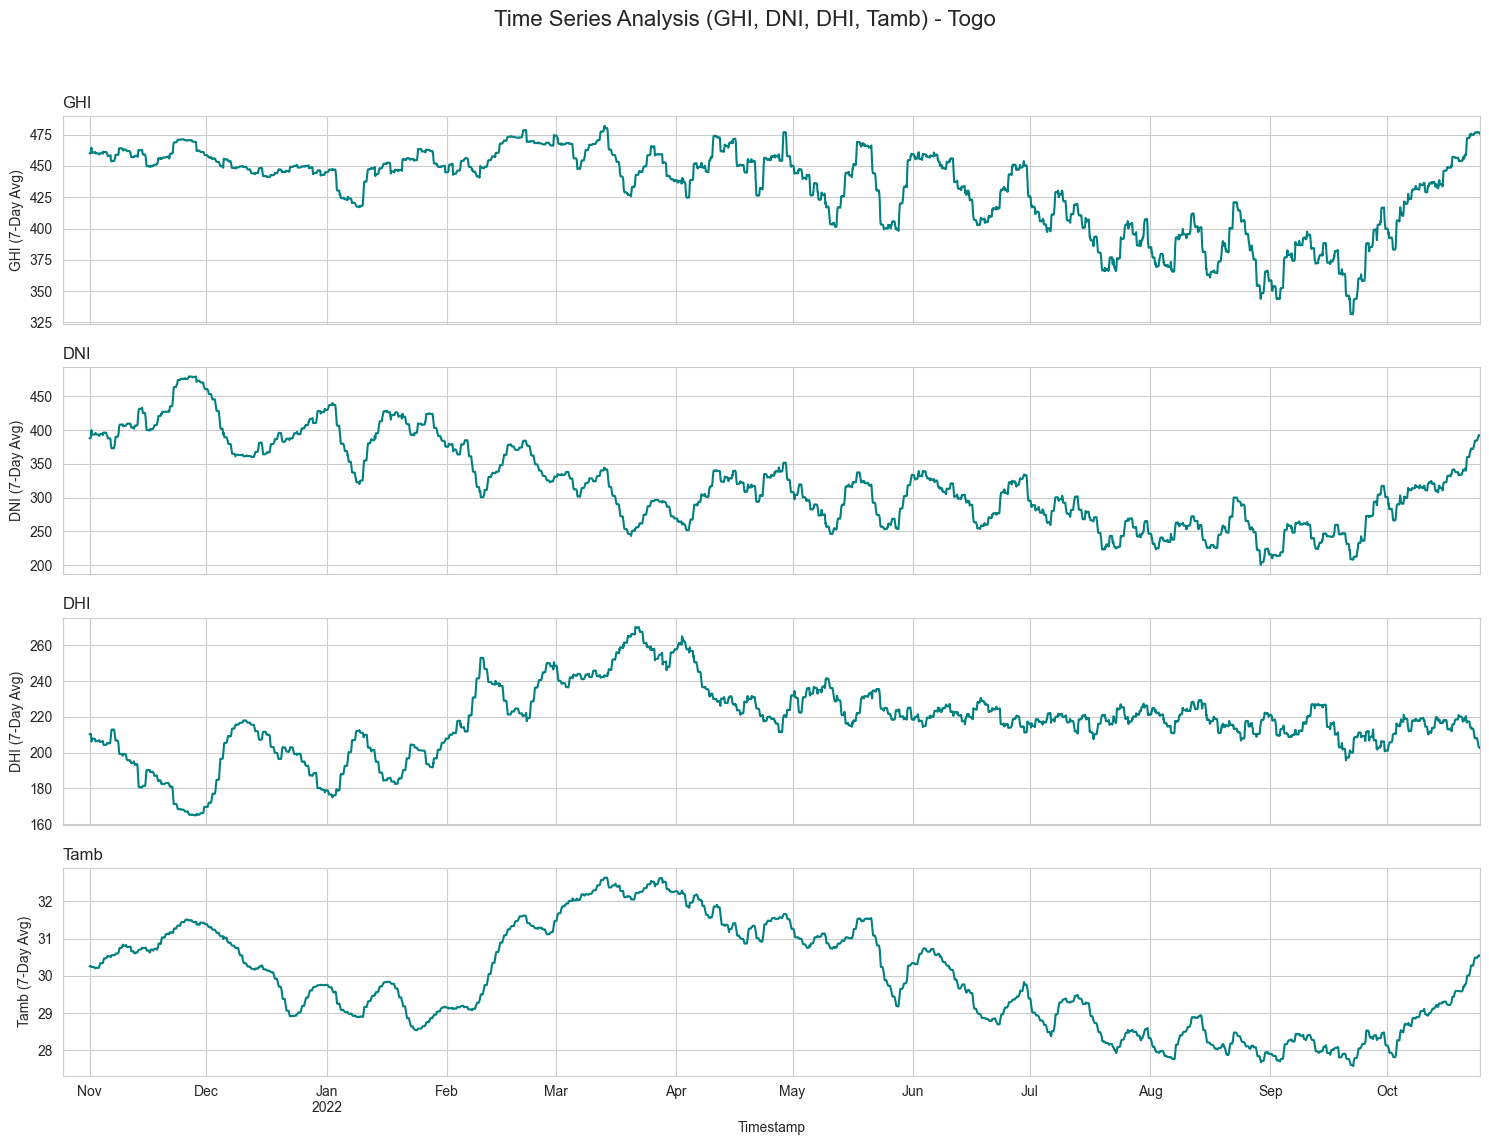

<Figure size 800x500 with 0 Axes>

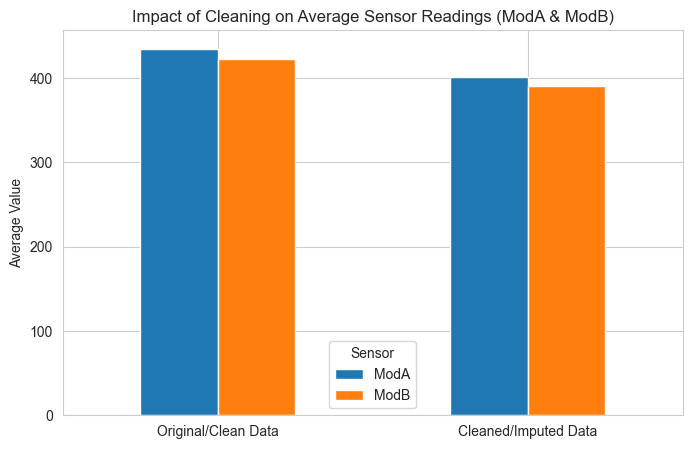

In [3]:
# Assuming df_clean is the cleaned DataFrame from Step 2.2

# --- Time Series Analysis: GHI, DNI, DHI, Tamb vs. Timestamp ---
variables = ['GHI', 'DNI', 'DHI', 'Tamb']
fig, axes = plt.subplots(len(variables), 1, figsize=(15, 12), sharex=True)
plt.suptitle('Time Series Analysis (GHI, DNI, DHI, Tamb) - Togo', fontsize=16)

for i, var in enumerate(variables):
    # Use 'h' for hourly resampling and 7-day rolling average
    df_clean[var].resample('h').mean().rolling(window=7*24).mean().plot(ax=axes[i], color='teal')
    axes[i].set_title(var, loc='left')
    axes[i].set_ylabel(var + ' (7-Day Avg)')

plt.xlabel("Timestamp")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Cleaning Impact: Pre/Post-Clean ModA & ModB ---
cleaning_impact = df_clean.groupby('Cleaning_Flag')[['ModA', 'ModB']].mean()

# Adjust index labels based on the number of groups returned (1 or 2)
if len(cleaning_impact) == 2:
    cleaning_impact.index = ['Original/Clean Data', 'Cleaned/Imputed Data']
elif len(cleaning_impact) == 1:
    cleaning_impact.index = ['All Data (Required Cleaning/Correction)']

plt.figure(figsize=(8, 5))
cleaning_impact.plot(kind='bar', figsize=(8, 5), rot=0)
plt.title('Impact of Cleaning on Average Sensor Readings (ModA & ModB)')
plt.ylabel('Average Value')
plt.legend(title='Sensor')
plt.show()

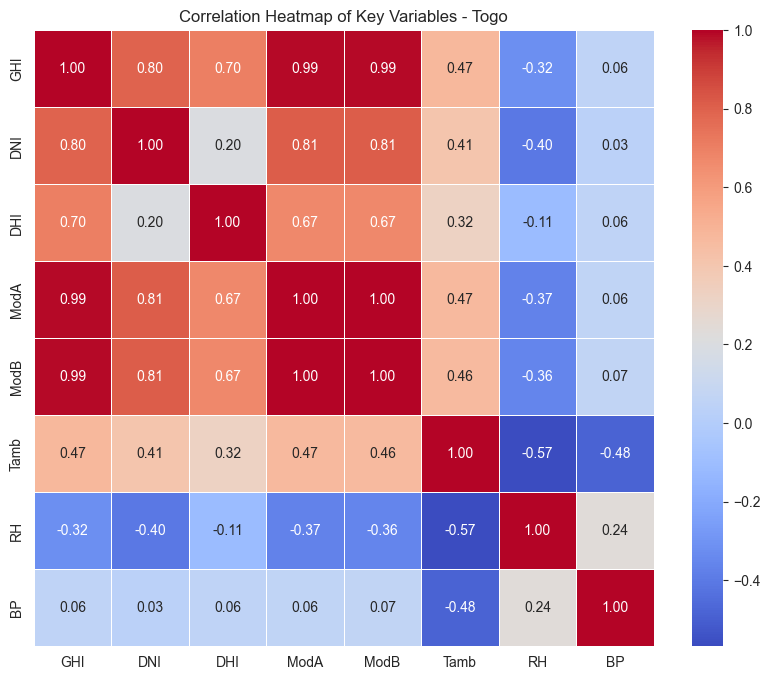

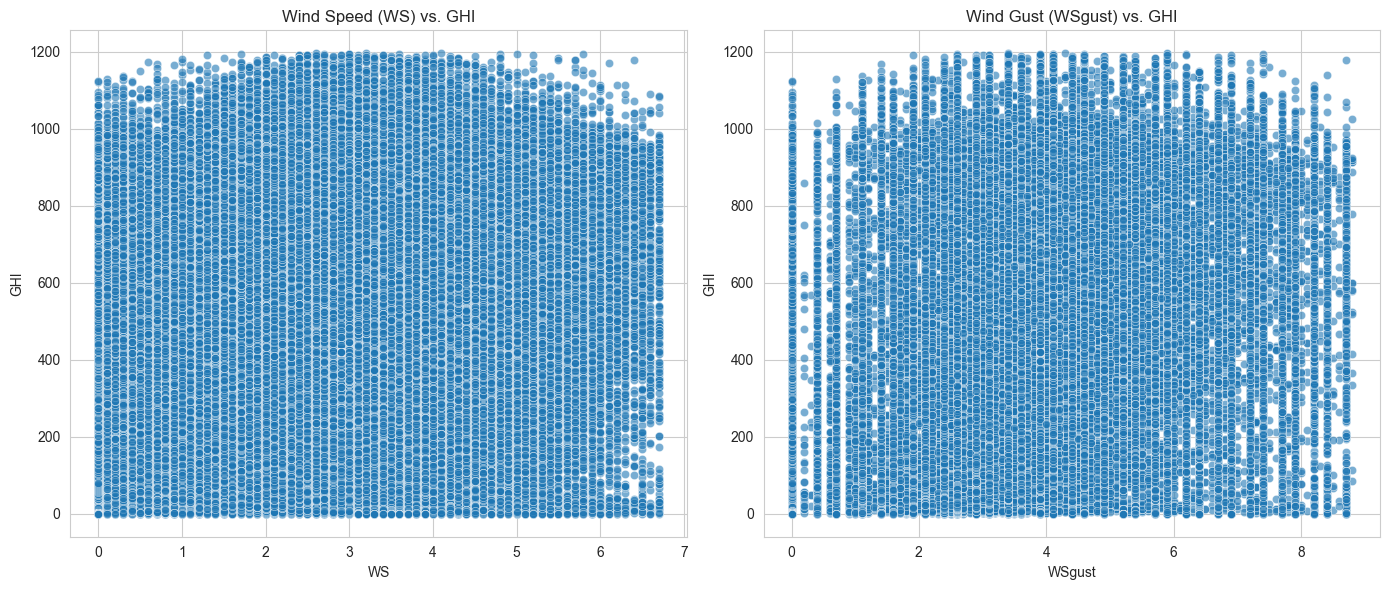

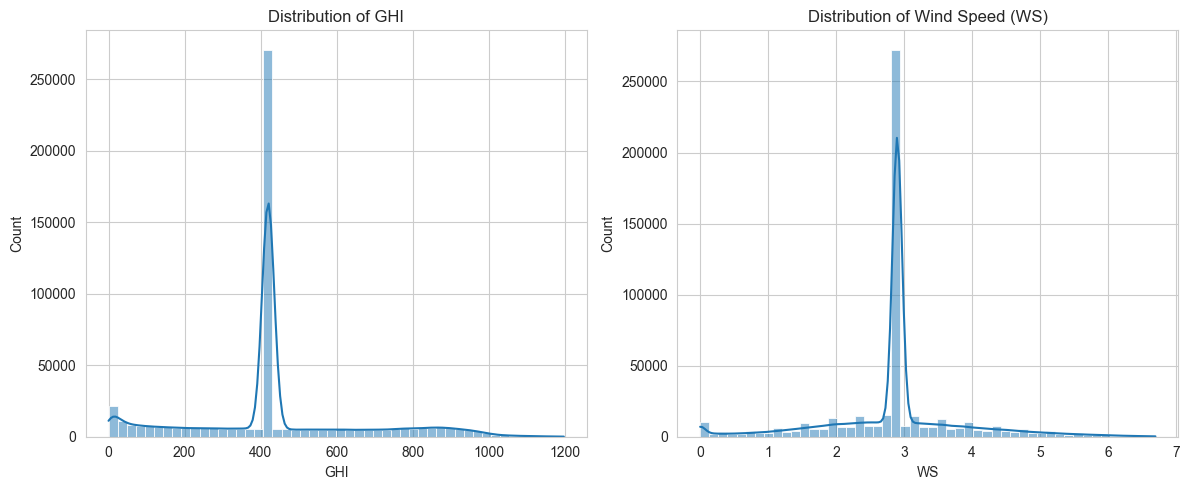

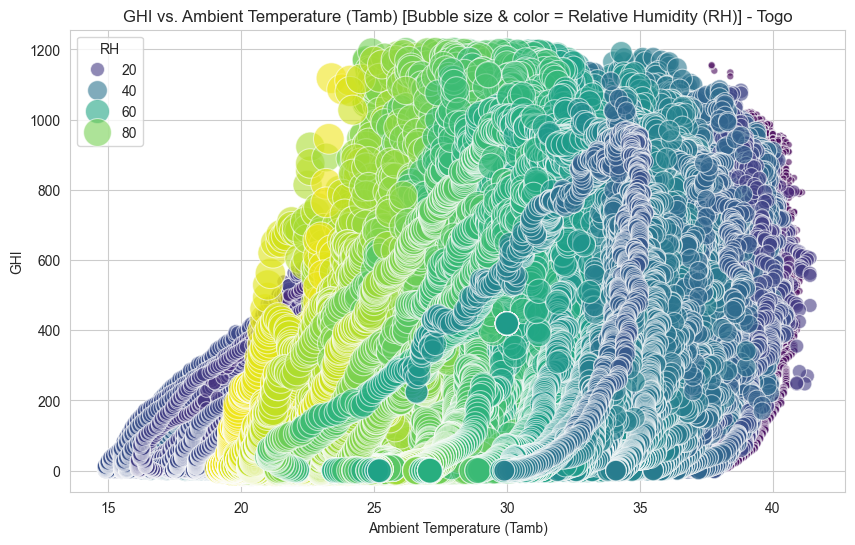

In [4]:
# --- Correlation Heatmap ---
corr_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'BP']
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Key Variables - Togo')
plt.show()

# --- Scatter Plot: WS, WSgust vs. GHI ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x='WS', y='GHI', data=df_clean, alpha=0.6, ax=axes[0])
axes[0].set_title('Wind Speed (WS) vs. GHI')

sns.scatterplot(x='WSgust', y='GHI', data=df_clean, alpha=0.6, ax=axes[1])
axes[1].set_title('Wind Gust (WSgust) vs. GHI')

plt.tight_layout()
plt.show()


# --- Histograms for GHI and WS (Distribution Analysis) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_clean['GHI'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of GHI')

sns.histplot(df_clean['WS'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Wind Speed (WS)')

plt.tight_layout()
plt.show()


# --- Bubble Chart: GHI vs. Tamb with bubble size = RH ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Tamb', y='GHI', size='RH', sizes=(20, 500), 
    data=df_clean, alpha=0.6, hue='RH', palette='viridis'
)
plt.title('GHI vs. Ambient Temperature (Tamb) [Bubble size & color = Relative Humidity (RH)] - Togo')
plt.xlabel('Ambient Temperature (Tamb)')
plt.ylabel('GHI')
plt.show()